# Step 1: Read and Inspect Data
1.) How many observations and how many varibales are there in the dataset? Can you find your proposed variables in the dataset?
    If not, what variables can you use as substitutes?
    
2.) Articulate your research question and clarify which variables you will investigate. 

3.) What are the dtype's of your main variables? Are there any missing values?

In [3]:
import pandas as pd
import numpy as np

path = 'https://raw.githubusercontent.com/UC-MACSS/persp-analysis/master/assignments/exploratory-data-analysis/data/gss2012.csv'

df = pd.read_csv(path, header=0)  

In [4]:
df.head()

,year,id,wrkstat,wrkslf,wrkgvt,marital,sibs,childs,age,educ,...,south,divlaw2,age.f,mslm_spk.high,mslm_spk.yes,grass.legal,age2,relig2,dem,science_quiz.f
0,2012,1.0,WORKING PART TIME,SOMEONE ELSE,PRIVATE,Never married,1.0,0.0,22.0,4 years,...,Nonsouth,More difficult,22.0,0.0,0.0,NaN,<=30,Catholic,0.0,NaN
1,2012,2.0,WORKING PART TIME,SOMEONE ELSE,PRIVATE,Never married,2.0,0.0,21.0,12th grade,...,Nonsouth,NaN,21.0,0.0,0.0,100.0,<=30,Catholic,0.0,7.0
2,2012,3.0,WORKING FULL TIME,SOMEONE ELSE,PRIVATE,Married,1.0,2.0,42.0,12th grade,...,Nonsouth,NaN,42.0,1.0,100.0,100.0,>=31,Protestant,0.0,10.0
3,2012,4.0,NaN,SOMEONE ELSE,PRIVATE,Married,2.0,2.0,49.0,1 yr coll,...,Nonsouth,Same/easier,49.0,NaN,NaN,100.0,>=31,Protestant,0.0,NaN
4,2012,5.0,RETIRED,SOMEONE ELSE,GOVERNMENT,Separated,0.0,3.0,70.0,4 years,...,Nonsouth,Same/easier,70.0,NaN,NaN,0.0,>=31,Protestant,1.0,4.0


### 1.) There are 1974 observations and 221 variables. I was not able to find every variable that i wanted so i used 'income06' as a substitute for my income variable, and 'size' as a substitute for my 'xnorcsize' variable.

In [5]:
df.columns.values

array(['year', 'id', 'wrkstat', 'wrkslf', 'wrkgvt', 'marital', 'sibs',
       'childs', 'age', 'educ', 'degree', 'sex', 'race', 'polviews',
       'partyid', 'mobile16', 'born', 'income06', 'rincom06', 'region',
       'size', 'vote08_coded', 'pres08', 'natspac', 'natenvir', 'natheal',
       'natcity', 'natcrime', 'natdrug', 'nateduc', 'natrace', 'natarms',
       'nataid', 'natfare', 'natroad', 'natsoc', 'natmass', 'natpark',
       'natchld', 'natsci', 'natenrgy', 'eqwlth', 'spkath', 'colath',
       'libath', 'spkrac', 'colrac', 'librac', 'spkcom', 'colcom',
       'libcom', 'spkmil', 'colmil', 'libmil', 'spkhomo', 'colhomo',
       'libhomo', 'spkmslm', 'colmslm', 'libmslm', 'cappun', 'gunlaw',
       'courts', 'grass', 'relig', 'fund', 'attend', 'reliten',
       'postlife', 'pray', 'bible', 'affrmact', 'wrkwayup', 'closeblk',
       'closewht', 'happy', 'confinan', 'conbus', 'conclerg', 'coneduc',
       'confed', 'conlabor', 'conpress', 'conmedic', 'contv', 'conjudge',
       '

### 2.) Do full time employees struggle to have children when comparing large city dwellers to those living in smaller towns?

In [6]:
data = df[['wrkstat', 'childs', 'sex', 'race', 'born', 'income06', 'size', 'id', 'age', 'educ']]

In [7]:
data.head()

,wrkstat,childs,sex,race,born,income06,size,id,age,educ
0,WORKING PART TIME,0.0,Male,White,YES,$150000 OR OVER,14,1.0,22.0,4 years
1,WORKING PART TIME,0.0,Male,White,YES,$150000 OR OVER,14,2.0,21.0,12th grade
2,WORKING FULL TIME,2.0,Male,Other,YES,$110000 TO $129999,14,3.0,42.0,12th grade
3,NaN,2.0,Female,White,YES,$130000 TO $149999,14,4.0,49.0,1 yr coll
4,RETIRED,3.0,Female,Black,YES,$50000 TO 59999,24,5.0,70.0,4 years


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   wrkstat   1919 non-null   object 
 1   childs    1971 non-null   float64
 2   sex       1974 non-null   object 
 3   race      1974 non-null   object 
 4   born      1971 non-null   object 
 5   income06  1758 non-null   object 
 6   size      1974 non-null   int64  
 7   id        1974 non-null   float64
 8   age       1969 non-null   float64
 9   educ      1972 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 154.3+ KB


### 3.) The dtype's of my main variables are 'childs', 64 bit float; 'wrkstat', object ; 'size', 64 bit integer.

In [9]:
data.childs.describe()

count    1971.000000
mean        1.891933
std         1.674530
min         0.000000
25%         0.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: childs, dtype: float64

In [28]:
data.wrkstat.describe()

count                  1919
unique                    7
top       WORKING FULL TIME
freq                    912
Name: wrkstat, dtype: object

In [10]:
data.groupby('size')

In [11]:
data.groupby('size').size()

size
0        17
1        82
2        50
3       122
4        63
       ... 
1526      6
2099     14
2696     14
3793     18
8175     41
Length: 146, dtype: int64

In [12]:
data.groupby('size').describe()

childs                                                   id               \
      count      mean       std  min   25%  50%  75%  max  count         mean   
size                                                                            
0      17.0  2.823529  1.424574  0.0  2.00  3.0  4.0  5.0   17.0  1818.647059   
1      82.0  2.219512  1.975307  0.0  0.25  2.0  3.0  8.0   82.0  1653.878049   
2      50.0  1.780000  1.217056  0.0  1.00  2.0  2.0  5.0   50.0  1390.820000   
3     122.0  2.016393  1.465773  0.0  1.00  2.0  3.0  8.0  122.0  1335.836066   
4      63.0  1.904762  1.701179  0.0  1.00  2.0  3.0  8.0   63.0  1479.873016   
...     ...       ...       ...  ...   ...  ...  ...  ...    ...          ...   
1526    6.0  2.333333  3.141125  0.0  0.00  1.5  3.0  8.0    6.0   473.500000   
2099   14.0  2.285714  1.589803  0.0  1.25  2.0  3.0  6.0   14.0   496.785714   
2696   14.0  2.000000  1.300887  0.0  1.25  2.0  2.0  4.0   14.0   233.500000   
3793   18.0  1.666667  1.414214  0.0  1.00  1.5  2.0  5.0   18.0   157.500000   
8175   41.0  1.560976  1.397297  0.0  0.00  2.0  2.0  6.0   41.0    81.487805   

      ...                     age                                           \
      ...      75%     max  count       mean        std   min    25%   50%   
size  ...                                                                    
0     ...  1854.00  1858.0   17.0  58.117647  20.127352  21.0  48.00  68.0   
1     ...  1830.75  1974.0   82.0  51.158537  19.417740  18.0  36.00  52.5   
2     ...  1874.25  1958.0   50.0  54.820000  19.356684  20.0  36.75  55.5   
3     ...  1466.75  1861.0  122.0  49.721311  18.034523  20.0  37.00  49.0   
4     ...  1909.50  1940.0   63.0  47.666667  16.672365  19.0  33.00  49.0   
...   ...      ...     ...    ...        ...        ...   ...    ...   ...   
1526  ...   474.75   476.0    6.0  50.833333  16.363577  31.0  39.75  51.0   
2099  ...   501.75   505.0   14.0  43.285714  15.444335  22.0  33.25  42.0   
2696  ...   236.75   240.0   14.0  48.928571  18.070223  26.0  34.25  46.0   
3793  ...   161.75   166.0   18.0  42.222222  15.341430  18.0  29.50  41.5   
8175  ...    95.00   105.0   39.0  46.948718  17.543853  19.0  33.50  47.0   

                   
        75%   max  
size               
0     74.00  82.0  
1     66.50  89.0  
2     71.00  89.0  
3     61.75  87.0  
4     61.00  84.0  
...     ...   ...  
1526  57.00  77.0  
2099  51.50  75.0  
2696  61.00  89.0  
3793  51.50  66.0  
8175  53.00  84.0  

[146 rows x 24 columns]

### Step 2.) I'm missing 216 values in the income column but that's not one of the 3 variables I'm focusing on. I will also have to change 'id' from a float to an object but I also don't have to do that yet. The'size' variable is very difficult to make sense of but i'll try to use it the best I can.

In [13]:
data.income06.describe()

count                1758
unique                 25
top       $60000 TO 74999
freq                  153
Name: income06, dtype: object

In [14]:
data.income06.info

AttributeError: 'Series' object has no attribute 'info'

In [15]:
data.groupby('income06').size()

income06
$1 000 TO 2 999        25
$10000 TO 12499        77
$110000 TO $129999     68
$12500 TO 14999        63
$130000 TO $149999     45
$15000 TO 17499        58
$150000 OR OVER       144
$17500 TO 19999        48
$20000 TO 22499        66
$22500 TO 24999        60
$25000 TO 29999        93
$3 000 TO 3 999        18
$30000 TO 34999        89
$35000 TO 39999       101
$4 000 TO 4 999        10
$40000 TO 49999       151
$5 000 TO 5 999         8
$50000 TO 59999       118
$6 000 TO 6 999        22
$60000 TO 74999       153
$7 000 TO 7 999        24
$75000 TO $89999      151
$8 000 TO 9 999        38
$90000 TO $109999     104
UNDER $1 000           24
dtype: int64

In [16]:
df.columns.size()

TypeError: 'int' object is not callable

In [17]:
df.shape

(1974, 221)

In [18]:
df_copy = pd.read_csv(path, header=0) 
df_drop_select = df_copy.dropna(subset=['income06'])
df_drop_select.shape

(1758, 221)

In [19]:
df_drop_emptyrow = df_copy.dropna(how='all')
df_drop_emptycol = df_copy.dropna(axis=1, how='all')

print(df_drop_emptyrow.shape)
print(df_drop_emptycol.shape)


(1974, 221)
(1974, 221)


In [20]:
df_drop_select.shape

(1758, 221)

### Step 3.) I decided 

# I love you
## I love mark down cells
### is this all i need to know?
- i hope this helps

In [22]:
data.head()

,wrkstat,childs,sex,race,born,income06,size,id,age,educ
0,WORKING PART TIME,0.0,Male,White,YES,$150000 OR OVER,14,1.0,22.0,4 years
1,WORKING PART TIME,0.0,Male,White,YES,$150000 OR OVER,14,2.0,21.0,12th grade
2,WORKING FULL TIME,2.0,Male,Other,YES,$110000 TO $129999,14,3.0,42.0,12th grade
3,NaN,2.0,Female,White,YES,$130000 TO $149999,14,4.0,49.0,1 yr coll
4,RETIRED,3.0,Female,Black,YES,$50000 TO 59999,24,5.0,70.0,4 years


In [23]:
data['size'] = data['size'] * 1000

C:\Users\DELROY~1.NIC\AppData\Local\Temp/ipykernel_46988/3502721405.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['size'] = data['size'] * 1000


In [24]:
data.loc[:, 'size'] = data['size'] * 1000

C:\Users\Delroy.Nichols\anaconda3\lib\site-packages\pandas\core\indexing.py:1773: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


### Adjusting the size variable to reflect the actual population.

In [25]:
df_copy['size'] = df_copy['size'] * 1000

In [26]:
df_copy.head()

,year,id,wrkstat,wrkslf,wrkgvt,marital,sibs,childs,age,educ,...,south,divlaw2,age.f,mslm_spk.high,mslm_spk.yes,grass.legal,age2,relig2,dem,science_quiz.f
0,2012,1.0,WORKING PART TIME,SOMEONE ELSE,PRIVATE,Never married,1.0,0.0,22.0,4 years,...,Nonsouth,More difficult,22.0,0.0,0.0,NaN,<=30,Catholic,0.0,NaN
1,2012,2.0,WORKING PART TIME,SOMEONE ELSE,PRIVATE,Never married,2.0,0.0,21.0,12th grade,...,Nonsouth,NaN,21.0,0.0,0.0,100.0,<=30,Catholic,0.0,7.0
2,2012,3.0,WORKING FULL TIME,SOMEONE ELSE,PRIVATE,Married,1.0,2.0,42.0,12th grade,...,Nonsouth,NaN,42.0,1.0,100.0,100.0,>=31,Protestant,0.0,10.0
3,2012,4.0,NaN,SOMEONE ELSE,PRIVATE,Married,2.0,2.0,49.0,1 yr coll,...,Nonsouth,Same/easier,49.0,NaN,NaN,100.0,>=31,Protestant,0.0,NaN
4,2012,5.0,RETIRED,SOMEONE ELSE,GOVERNMENT,Separated,0.0,3.0,70.0,4 years,...,Nonsouth,Same/easier,70.0,NaN,NaN,0.0,>=31,Protestant,1.0,4.0


In [27]:
data_copy = df_copy[['wrkstat', 'childs', 'sex', 'race', 'born', 'income06', 'size', 'id', 'age', 'educ']]

In [28]:
data_copy.head()

,wrkstat,childs,sex,race,born,income06,size,id,age,educ
0,WORKING PART TIME,0.0,Male,White,YES,$150000 OR OVER,14000,1.0,22.0,4 years
1,WORKING PART TIME,0.0,Male,White,YES,$150000 OR OVER,14000,2.0,21.0,12th grade
2,WORKING FULL TIME,2.0,Male,Other,YES,$110000 TO $129999,14000,3.0,42.0,12th grade
3,NaN,2.0,Female,White,YES,$130000 TO $149999,14000,4.0,49.0,1 yr coll
4,RETIRED,3.0,Female,Black,YES,$50000 TO 59999,24000,5.0,70.0,4 years


In [33]:
df.size.describe()

AttributeError: 'numpy.int32' object has no attribute 'describe'

### Troubleshooting the type error.

In [34]:
type(data_copy)

pandas.core.frame.DataFrame

In [35]:
data_copy.columns

Index(['wrkstat', 'childs', 'sex', 'race', 'born', 'income06', 'size', 'id',
       'age', 'educ'],
      dtype='object')

In [36]:
data_copy.size

19740

In [37]:
data_copy['size'].describe()

count    1.974000e+03
mean     3.597974e+05
std      1.244763e+06
min      0.000000e+00
25%      7.000000e+03
50%      2.900000e+04
75%      1.270000e+05
max      8.175000e+06
Name: size, dtype: float64

### Defining population thresholds for my categories.

In [38]:
populations = [0, 50000, 500000, 8175000]
labels = ['small_town', 'large_town', 'city']

### Creating a new categorical variable based on the population sets best suited for my research question.

In [40]:
df_copy['locality'] = pd.cut(data['size'], bins=populations, labels=labels)

### Now I can use the locality varibale for my analysis and visualizations.

In [41]:
df_copy['locality'].describe()

count      513
unique       1
top       city
freq       513
Name: locality, dtype: object

In [43]:
df_copy['locality'].unique()

[NaN, 'city']
Categories (3, object): ['small_town' < 'large_town' < 'city']

In [44]:
df_copy['locality'].value_counts()

city          513
small_town      0
large_town      0
Name: locality, dtype: int64

In [46]:
import matplotlib.pyplot as plt

(array([1827.,   60.,   14.,   14.,   18.,    0.,    0.,    0.,    0.,
          41.]),
 array([      0.,  817500., 1635000., 2452500., 3270000., 4087500.,
        4905000., 5722500., 6540000., 7357500., 8175000.]),
 <BarContainer object of 10 artists>)

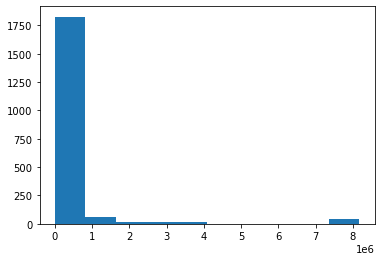

In [47]:
plt.hist(df_copy['size'])

(array([1827.,   60.,   14.,   14.,   18.,    0.,    0.,    0.,    0.,
          41.]),
 array([   0. ,  817.5, 1635. , 2452.5, 3270. , 4087.5, 4905. , 5722.5,
        6540. , 7357.5, 8175. ]),
 <BarContainer object of 10 artists>)

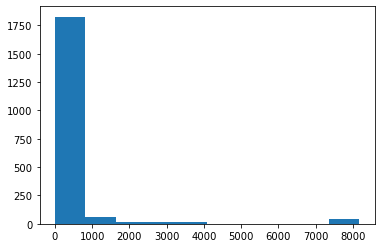

In [48]:
plt.hist(df['size'])

In [49]:
df['size'].describe()

count    1974.000000
mean      359.797366
std      1244.762836
min         0.000000
25%         7.000000
50%        29.000000
75%       127.000000
max      8175.000000
Name: size, dtype: float64

In [50]:
df['size'].isna().sum()

0

In [51]:
df_copy['size'].isna().sum()

0

In [52]:
df_copy['size'].describe()

count    1.974000e+03
mean     3.597974e+05
std      1.244763e+06
min      0.000000e+00
25%      7.000000e+03
50%      2.900000e+04
75%      1.270000e+05
max      8.175000e+06
Name: size, dtype: float64

In [53]:
df_copy['locality'].isna().sum()

1461

In [54]:
data.groupby('size').size()

size
0              17
1000000        82
2000000        50
3000000       122
4000000        63
             ... 
1526000000      6
2099000000     14
2696000000     14
3793000000     18
8175000000     41
Length: 146, dtype: int64

In [55]:
data['size'] = data['size'] /1000

C:\Users\DELROY~1.NIC\AppData\Local\Temp/ipykernel_46988/1646595734.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['size'] = data['size'] /1000


In [56]:
data.groupby('size').size()

size
0.0           17
1000.0        82
2000.0        50
3000.0       122
4000.0        63
            ... 
1526000.0      6
2099000.0     14
2696000.0     14
3793000.0     18
8175000.0     41
Length: 146, dtype: int64

In [57]:
df_copy['size'].describe()

count    1.974000e+03
mean     3.597974e+05
std      1.244763e+06
min      0.000000e+00
25%      7.000000e+03
50%      2.900000e+04
75%      1.270000e+05
max      8.175000e+06
Name: size, dtype: float64

### Going to re-do the pd.cut now that i fixed the values.

In [83]:
df_copy['locality'] = pd.cut(data['size'], bins=populations, labels=labels)

In [84]:
df_copy['locality'].isna().sum()

17

(array([1827.,   60.,   14.,   14.,   18.,    0.,    0.,    0.,    0.,
          41.]),
 array([      0.,  817500., 1635000., 2452500., 3270000., 4087500.,
        4905000., 5722500., 6540000., 7357500., 8175000.]),
 <BarContainer object of 10 artists>)

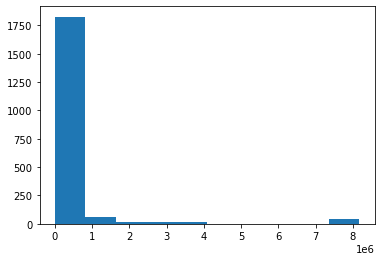

In [85]:
plt.hist(df_copy['size'])

TypeError: 'value' must be an instance of str or bytes, not a float

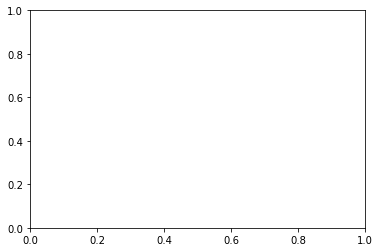

In [86]:
plt.hist(df_copy['locality'])

In [87]:
type(df_copy)

pandas.core.frame.DataFrame

In [88]:
type(data_copy)

pandas.core.frame.DataFrame

(array([1827.,   60.,   14.,   14.,   18.,    0.,    0.,    0.,    0.,
          41.]),
 array([      0.,  817500., 1635000., 2452500., 3270000., 4087500.,
        4905000., 5722500., 6540000., 7357500., 8175000.]),
 <BarContainer object of 10 artists>)

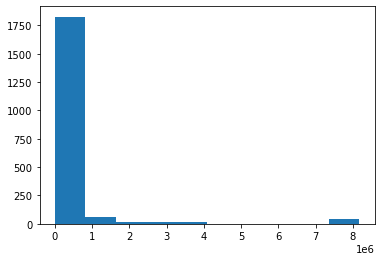

In [89]:
plt.hist(df_copy['size'])

In [90]:
df_copy.groupby('locality').size()

locality
small_town    1224
large_town     484
city           249
dtype: int64

TypeError: 'value' must be an instance of str or bytes, not a float

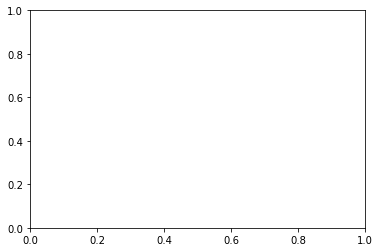

In [91]:
plt.hist(df_copy['locality'])
plt.show(df_copy['locality'])

In [92]:
df_copy['locality'] = df_copy['locality'].astype(str)

In [93]:
df_copy.groupby('locality').size()

locality
city           249
large_town     484
nan             17
small_town    1224
dtype: int64

In [94]:
missing_locality = df_copy[df_copy['locality'].isna()]
print(missing_locality)

Empty DataFrame
Columns: [wrkstat, childs, sex, race, born, income06, size, id, age, educ, locality]
Index: []


In [95]:
df_copy['locality'] = pd.Categorical(df_copy['locality'])
df_copy.groupby('locality').size()

locality
city           249
large_town     484
nan             17
small_town    1224
dtype: int64

In [96]:
locality_counts = df_copy.groupby('locality').size()

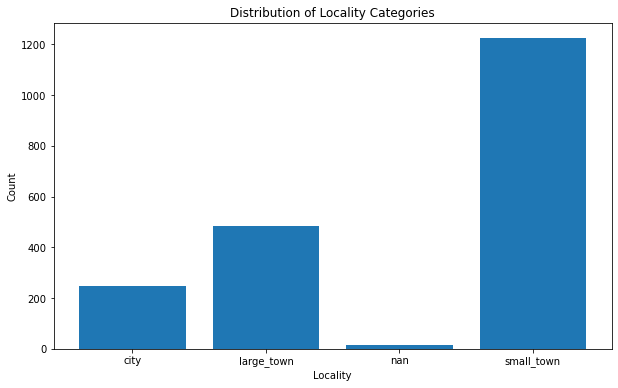

In [97]:
plt.figure(figsize=(10, 6))
plt.bar(locality_counts.index.astype(str), locality_counts.values)
plt.xlabel("Locality")
plt.ylabel("Count")
plt.title("Distribution of Locality Categories")
plt.show()

In [98]:
df_copy.groupby('size').size()

size
0.0           17
1000.0        82
2000.0        50
3000.0       122
4000.0        63
            ... 
1526000.0      6
2099000.0     14
2696000.0     14
3793000.0     18
8175000.0     41
Length: 146, dtype: int64

In [99]:
df_copy.groupby('locality').size()

locality
city           249
large_town     484
nan             17
small_town    1224
dtype: int64

In [120]:
data_copy['size'] = data_copy['size'].fillna(data_copy['size'].median())

In [101]:
df_copy.groupby('locality').size()

locality
city           249
large_town     484
nan             17
small_town    1224
dtype: int64

In [121]:
thresholds = [0, 50000, 500000, 8175000]
labels = ['small_town', 'large_town', 'city']
data_copy['locality'] = pd.cut(data_copy['size'], bins=thresholds, labels=labels)

In [122]:
data_copy['locality'] = pd.Categorical(data_copy['locality'])

In [123]:
locality_counts = data_copy.groupby('locality').size()

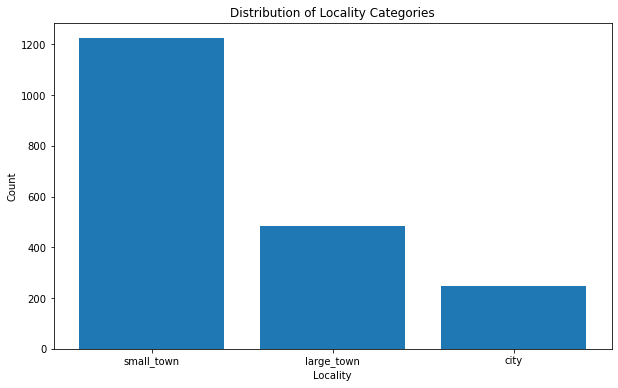

In [124]:
plt.figure(figsize=(10, 6))
plt.bar(locality_counts.index.astype(str), locality_counts.values)
plt.xlabel("Locality")
plt.ylabel("Count")
plt.title("Distribution of Locality Categories")
plt.show()

In [125]:
nan_rows_copy = df_copy[df_copy['locality'].isna()]

In [126]:
print("NaN rows in copy:")
print(nan_rows_copy)

NaN rows in copy:
Empty DataFrame
Columns: [wrkstat, childs, sex, race, born, income06, size, id, age, educ, locality]
Index: []


In [127]:
print(data_copy.groupby('locality').size())

locality
small_town    1224
large_town     484
city           249
dtype: int64


In [110]:
df_copy.groupby('locality').size()

locality
city           249
large_town     484
nan             17
small_town    1224
dtype: int64

In [129]:
print(data_copy['locality'].dtype)

category


In [130]:
data_copy.groupby('locality').size()

locality
small_town    1224
large_town     484
city           249
dtype: int64

In [131]:
data_copy['locality'].head()

0    small_town
1    small_town
2    small_town
3    small_town
4    small_town
Name: locality, dtype: category
Categories (3, object): ['small_town' < 'large_town' < 'city']

In [128]:
data_copy.groupby('locality').size()

locality
small_town    1224
large_town     484
city           249
dtype: int64

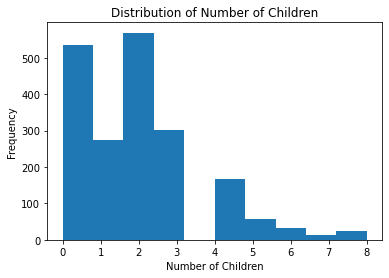

In [132]:
plt.hist(data_copy['childs'])
plt.xlabel('Number of Children')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Children')
plt.show()

### The univariate distribution in number of children definitely concerns me because there are a lot of inputs missing between 2 children and 3 children.

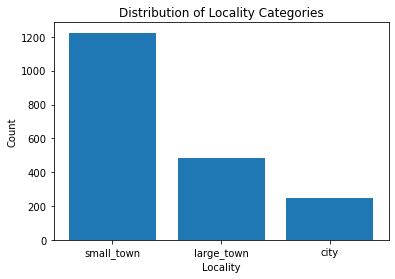

In [133]:
locality_counts = data_copy['locality'].value_counts()

plt.bar(locality_counts.index.astype(str), locality_counts.values)
plt.xlabel('Locality')
plt.ylabel('Count')
plt.title('Distribution of Locality Categories')
plt.show()

## The distribution of the locality categories represent a right-tailed distribution, meaning most respondents from this survey came from small towns.

In [134]:
mean_childs_by_locality = data_copy.groupby('locality')['childs'].mean()
print(mean_childs_by_locality)

locality
small_town    1.923895
large_town    1.900621
city          1.654618
Name: childs, dtype: float64


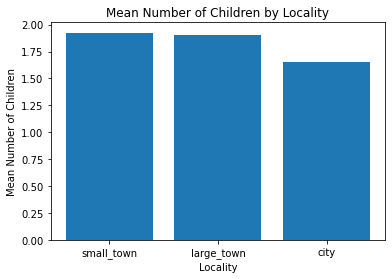

In [135]:
plt.bar(mean_childs_by_locality.index.astype(str), mean_childs_by_locality.values)
plt.xlabel('Locality')
plt.ylabel('Mean Number of Children')
plt.title('Mean Number of Children by Locality')
plt.show()

### We do see the impact we expected from Hypothesis A, which is, Respondents from small-towns are likely to have more children than people who live in the city.

In [136]:
data_copy['childs'].describe()

count    1971.000000
mean        1.891933
std         1.674530
min         0.000000
25%         0.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: childs, dtype: float64

In [137]:
data_copy['childs'].size()

TypeError: 'int' object is not callable

In [138]:
data_copy['childs'].unique()

array([ 0.,  2.,  3.,  6.,  4.,  5.,  8.,  1., nan,  7.])

In [140]:
data_copy['childs'].count()

1971

In [ ]:
data_copy['income_group'] = pd.cut(data_copy['avg_inc'], bins=[0, 20000, 39999.5, 79499.5, 120500, np.inf],
                                    labels=['<20k', '20k-39k', '40k-79k', '80k-120k', '121k and Above'])